###Задание 1

Обучить сеть Хопфилда распознавать 4 изображения 6*6

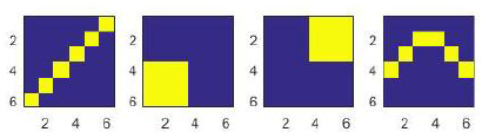

---

Подать на вход и скорректировать искаженный образ:


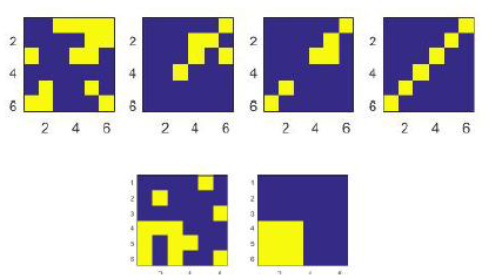

###Замечание

Из-за того, что сеть Хопфилда имеет свои недостатки, а именно маленький объем емкости памяти, то он может обучится только на 0,14*K оригинальных образцов, где K - размер пикселей

Т.е. 0.14*36 = 5 образцов

Благо, что у нас из обучающей, только 4 образов, иначе модель почувствовала бы деменцию (

####Загрузка необходимых библиотек

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

####Функция активации - сигнум

In [ ]:
def sign(z):
  return -1 if z <= 0 else 1

####Образцы изображений

In [ ]:
x1 = np.array([-1,-1,-1,-1,-1, 1,
               -1,-1,-1,-1, 1,-1,
               -1,-1,-1, 1,-1,-1,
               -1,-1, 1,-1,-1,-1,
               -1, 1,-1,-1,-1,-1,
                1,-1,-1,-1,-1,-1])

x2 = np.array([-1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,
                1, 1, 1,-1,-1,-1,
                1, 1, 1,-1,-1,-1,
                1, 1, 1,-1,-1,-1])

x3 = np.array([-1,-1,-1, 1, 1, 1,
               -1,-1,-1, 1, 1, 1,
               -1,-1,-1, 1, 1, 1,
               -1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,])

x4 = np.array([-1,-1,-1,-1,-1,-1,
               -1,-1, 1, 1,-1,-1,
               -1, 1,-1,-1, 1,-1,
                1,-1,-1,-1,-1, 1,
               -1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,])

good_train_1 = [x1,x2,x3,x4]

####Искаженные образцы

In [ ]:
t1 = np.array([-1,-1, 1, 1, 1, 1,
               -1,-1,-1,-1, 1, 1,
                1,-1,-1, 1, 1,-1,
               -1,-1,-1,-1,-1,-1,
               -1, 1,-1,-1, 1,-1,
                1, 1,-1,-1,-1, 1])

t2 = np.array([-1,-1,-1,-1,-1, 1,
               -1,-1,-1, 1, 1,-1,
               -1,-1,-1, 1,-1, 1,
               -1,-1, 1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1])

t3 = np.array([-1,-1,-1,-1,-1, 1,
               -1,-1,-1,-1, 1,-1,
               -1,-1,-1, 1, 1,-1,
               -1,-1,-1,-1,-1,-1,
               -1, 1,-1,-1,-1,-1,
                1,-1,-1,-1,-1,-1])

t4 = np.array([-1,-1,-1,-1,-1, 1,
               -1,-1,-1,-1, 1,-1,
               -1,-1,-1, 1,-1,-1,
               -1,-1, 1,-1,-1,-1,
               -1, 1,-1,-1,-1,-1,
                1,-1,-1,-1,-1,-1])

t5 = np.array([-1,-1,-1,-1, 1,-1,
               -1, 1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1, 1,
                1, 1, 1,-1,-1,-1,
                1,-1, 1, 1,-1,-1,
                1,-1, 1,-1,-1, 1])

t6 = np.array([-1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,
               -1,-1,-1,-1,-1,-1,
                1, 1, 1,-1,-1,-1,
                1, 1, 1,-1,-1,-1,
                1, 1, 1,-1,-1,-1])

good_test_1 = [t1,t2,t3,t4,t5,t6]

#### Структура Хопфилда и запуск его

Обучение на эталонных образцах

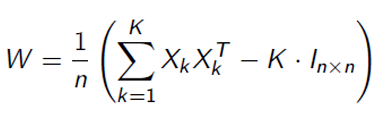

In [ ]:
N = 36
W_train = np.zeros((N, N))

#Правило Хэбба
for X in good_train_1:
  W_train += np.outer(X,X)
np.fill_diagonal(W_train, 0)

W_train /= N
print(W_train)


[[0.         0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]
 [0.11111111 0.         0.11111111 ... 0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.         ... 0.11111111 0.11111111 0.11111111]
 ...
 [0.11111111 0.11111111 0.11111111 ... 0.         0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111 ... 0.11111111 0.         0.11111111]
 [0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.        ]]




####Реализация асинхронного режима

In [ ]:
def asynchron_hopfild(cartoon_test, W, max_iter=100):
  test = cartoon_test.copy()
  pass_iteration = 0

  for _ in range(max_iter):
    i = np.random.randint(0, N)
    v = np.dot(W[i], test)

    new_state = sign(v)

    if test[i] == new_state:
      pass_iteration += 1
    else:
      test[i] = new_state
      pass_iteration = 0

    if pass_iteration >= N:
      break

  print(f"Количество затраченных итераций: {pass_iteration}")
  return test


Тестирование - Посчитаем точность предсказаний

In [ ]:
def print_image_z1(vector):
    matrix = vector.reshape((6, 6))
    for row in matrix:
        print(" ".join(["██" if val == 1 else "  " for val in row]))


In [ ]:
sum_correct = 0
for i in range(len(good_test_1)):
  cartoon = good_test_1[i]
  result = asynchron_hopfild(cartoon, W_train)
  print(f"Получившийся образец t{i+1}", result)
  print_image_z1(result)

  is_correct = False
  for index, pattern in enumerate(good_train_1):
    if np.array_equal(result, pattern):
      is_correct = True
      print(f"Совпавшие образец t{i+1}\n")
      print("-" * 20)
      break
  if is_correct:
    sum_correct += 1
  else:
    print(f"Полученный образ t{i+1} вообще не распознан\n")
    print("-" * 20)

accuracy = sum_correct / len(good_test_1)
print(f"\nВерно совпавших {sum_correct} из {len(good_test_1)}")
print(f"Точность предсказаний равна: {accuracy*100}%\n")

Количество затраченных итераций: 8
Получившийся образец t1 [-1 -1 -1 -1 -1  1 -1 -1 -1  1  1 -1 -1 -1 -1  1  1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
               ██
         ██ ██   
         ██ ██   
                 
                 
                 
Полученный образ t1 вообще не распознан

--------------------
Количество затраченных итераций: 36
Получившийся образец t2 [-1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1
 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1]
               ██
            ██   
         ██      
      ██         
   ██            
██               
Совпавшие образец t2

--------------------
Количество затраченных итераций: 36
Получившийся образец t3 [-1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1
 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1]
               ██
            ██   
         ██      
      ██         
   ██            
██               
Совпавшие образец t3

--------------------
Количество затра

###Задание 2

Построить двунаправленную ассоциативную память, связывающую изображения чисел 1,2,3 с их двоичными кодами.

Каждое число представляется матрицей 9*7.

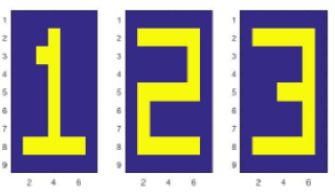

Испытать сеть на зашумленных вариантах изображений.

In [ ]:
def print_image_z2(vector):
    matrix = vector.reshape((9, 7))
    for row in matrix:
        print(" ".join(["██" if val == 1 else "  " for val in row]))
    print("-" * 25)

####Образцы изображений

In [ ]:
z1 = np.array(
    [-1, -1, -1,  1, -1, -1, -1,
    -1, -1,  1,  1, -1, -1, -1,
    -1,  1, -1,  1, -1, -1, -1,
    -1, -1, -1,  1, -1, -1, -1,
    -1, -1, -1,  1, -1, -1, -1,
    -1, -1, -1,  1, -1, -1, -1,
    -1, -1, -1,  1, -1, -1, -1,
    -1,  1,  1,  1,  1,  1, -1,
    -1, -1, -1, -1, -1, -1, -1]
     )

z2 = np.array(
    [-1,  1,  1,  1,  1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1,  1,  1,  1,  1,  1, -1,
    -1,  1, -1, -1, -1, -1, -1,
    -1,  1, -1, -1, -1, -1, -1,
    -1,  1,  1,  1,  1,  1, -1,
    -1, -1, -1, -1, -1, -1, -1]
)

z3 = np.array(
    [-1,  1,  1,  1,  1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1,  1,  1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1, -1, -1,  1, -1,
    -1,  1,  1,  1,  1,  1, -1,
    -1, -1, -1, -1, -1, -1, -1,
    -1, -1, -1, -1, -1, -1, -1]
)

z_train = [z1, z2, z3]

# Ассоциированные с ними являются трехбитовые двоичные числа
e1 = np.array([-1, -1, 1])
e2 = np.array([-1, 1, -1])
e3 = np.array([-1, 1, 1])

e_train = [e1, e2, e3]

####Тестовая выборка

Генерируются 3 зашумленные картинки для каждой эталонной картинки z1,z2,z3

Просто берется из каждой эталонной картинке и меняются 3 пикселя и сохраняем зашумленное изображение

In [ ]:
good_test_2 = []
true_labels = [] #индексы правильных ответов

for idx, clean_img in enumerate(z_train):
    for variant in range(2):
        noisy_img = clean_img.copy()

        pix_flip = np.random.choice(63, size=20, replace=False)

        for pix in pix_flip:
            noisy_img[pix] *= -1

        good_test_2.append(noisy_img)
        true_labels.append(idx) #Изначальные числа

print(good_test_2)
print()
print(true_labels)


[array([ 1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1,
        1, -1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1,
       -1, -1,  1, -1,  1, -1, -1,  1, -1, -1, -1, -1,  1,  1, -1, -1,  1,
        1,  1,  1, -1, -1, -1, -1,  1, -1, -1,  1, -1]), array([-1,  1,  1,  1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1,  1, -1, -1, -1,  1, -1,  1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1,  1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1,
        1,  1,  1,  1, -1, -1, -1,  1, -1,  1,  1, -1]), array([ 1, -1,  1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1, -1,  1, -1,
        1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1,  1,  1, -1,  1,
       -1, -1,  1,  1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1,  1,
        1,  1,  1, -1, -1, -1,  1,  1,  1,  1, -1,  1]), array([ 1,  1,  1,  1,  1,  1, -1, -1, -1,  1, -1,  1, -1,  1,  1, -1,  1,
       -1, -1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1, -1,  1,  1,  1,  1,
   

Обучение по обучающей выборке

In [ ]:
size_x = 63
size_y = 3

W_dam = np.zeros((size_x, size_y))

#Правило Хэбба
for x, y in zip(z_train, e_train):
  W_dam += np.outer(x, y)

W_dam /= len(z_train)
print(W_dam)

[[ 1.         -0.33333333 -0.33333333]
 [-0.33333333  1.         -0.33333333]
 [-0.33333333  1.         -0.33333333]
 [-1.          0.33333333  0.33333333]
 [-0.33333333  1.         -0.33333333]
 [-0.33333333  1.         -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 0.33333333 -1.          0.33333333]
 [ 0.33333333 -1.          0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [-0.33333333  1.         -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 0.33333333 -1.          0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 0.33333333 -1.          0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [-0.33333333  1.         -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [ 1.         -0.33333333 -0.33333333]
 [-0.33333333 -0.33333333  1.        ]
 [ 0.33333333  0.33333333

Предсказание по тестовой выборке

In [ ]:
def processing_dam(cartoon_test, W_dam, max_iter=100):
  xcurr = cartoon_test.copy()

  ycurr = sign(np.dot(xcurr, W_dam))
  for i in range(max_iter):
    xnext = sign(np.dot(W_dam, ycurr))
    ynext = sign(np.dot(xnext, W_dam))
    if np.array_equal(xcurr, xnext) and np.array_equal(ycurr, ynext):
      print(f"Равновесие получилась на шаге {i+1}")
      break
    xcurr = xnext.copy()
    ycurr = ynext.copy()
  return xcurr, ycurr

####Тестирование программы

In [ ]:
def sign(z):
    return np.where(z >= 0, 1, -1)

In [ ]:
sum_correct = 0
for i in range(len(good_test_2)):
  cartoon = good_test_2[i]
  correct_idx = true_labels[i]

  result_x, result_y = processing_dam(cartoon, W_dam)
  print(f"Что вернуло для конкретного cartoon-{cartoon}, а именно result_x: {result_x} и result_y: {result_y}")
  if np.array_equal(result_y, e_train[correct_idx]):
      print(f"Успешно совпало!")
      sum_correct += 1
  else:
      print(f"Не совпало")

  print("\nВосстановленная картинка на выходе:")
  print_image_z2(result_x)



accuracy = sum_correct / len(good_test_2)
print(f"\nВерно совпавших {sum_correct} из {len(good_test_2)}")
print(f"Точность предсказаний равна: {accuracy*100}%\n")

Равновесие получилась на шаге 2
Что вернуло для конкретного cartoon-[ 1 -1 -1  1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1  1 -1  1 -1 -1  1 -1  1 -1
  1  1  1  1  1 -1  1  1 -1 -1 -1 -1  1 -1  1 -1 -1  1 -1 -1 -1 -1  1  1
 -1 -1  1  1  1  1 -1 -1 -1 -1  1 -1 -1  1 -1], а именно result_x: [-1 -1 -1  1 -1 -1 -1 -1 -1  1  1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1 -1 -1
  1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1
 -1 -1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1] и result_y: [-1 -1  1]
Успешно совпало!

Восстановленная картинка на выходе:
         ██         
      ██ ██         
   ██    ██         
         ██         
         ██         
         ██         
         ██         
   ██ ██ ██ ██ ██   
                    
-------------------------
Равновесие получилась на шаге 2
Что вернуло для конкретного cartoon-[-1  1  1  1 -1 -1 -1  1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1  1  1 -1 -1 -1
  1 -1  1 -1 -1  1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1 -1 -1 -1 -1 -1
  1 -1  1  1  1  1  

###Задание 3

Построить двунаправленную ассоциативную память, связывающую изображения из файла arrow.bmp (размер 32*32 пикселей)

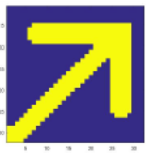

с его сжатым вариантом pressed_arrow.bmp (размер 16*16 пикселей).

Испытать сеть на зашумленных вариантах изображений.

In [ ]:
#Подключение к Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Здесь же применим уже реализованную функцию processing_dam

Ниже представлена функция, которая конвертирует изображение в биполярное множество

In [ ]:
def load_and_binarize_image(filepath, target_size):
    img = Image.open(filepath).convert('L').resize(target_size)
    img_array = np.array(img)
    return np.where(img_array > 128, 1, -1).flatten()

Обучение по правилу Хэбба

In [ ]:
X_train = load_and_binarize_image("arrow.bmp", (32, 32))        # Размер: 1024
Y_train = load_and_binarize_image("pressed_arrow.bmp", (16, 16)) # Размер: 256

W_dam = np.outer(X_train, Y_train)

Тестирование

Равновесие получилась на шаге 2


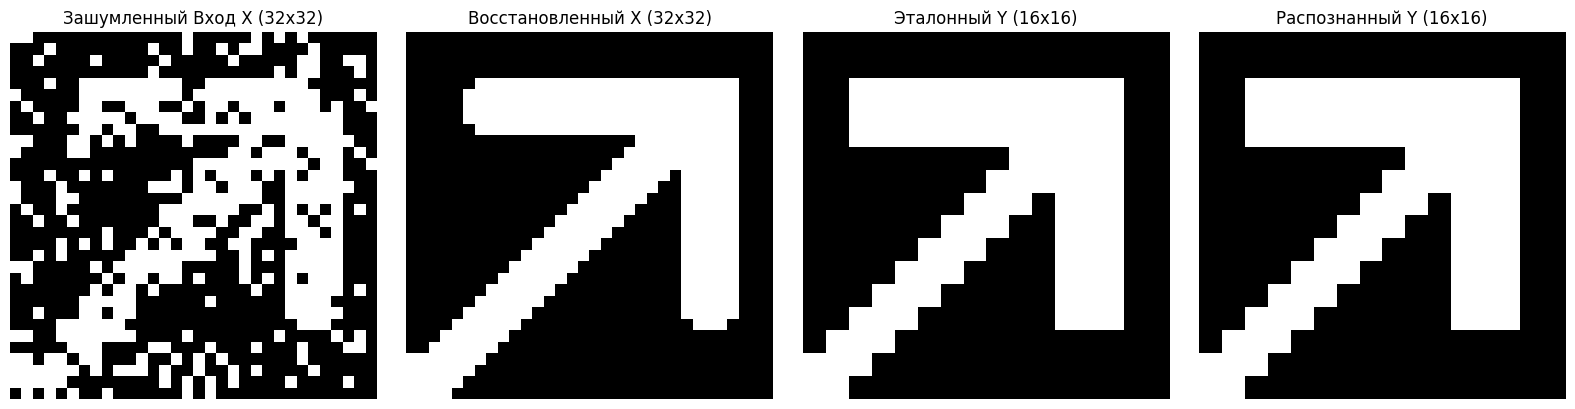

In [ ]:
X_noisy = X_train.copy()

noise_pixels = np.random.choice(1024, size=200, replace=False)
for p in noise_pixels:
    X_noisy[p] *= -1

X_recovered, Y_recovered = processing_dam(X_noisy, W_dam)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(X_noisy.reshape(32, 32), cmap='gray')
axes[0].set_title('Зашумленный Вход X (32x32)')
axes[0].axis('off')

axes[1].imshow(X_recovered.reshape(32, 32), cmap='gray')
axes[1].set_title('Восстановленный X (32x32)')
axes[1].axis('off')

axes[2].imshow(Y_train.reshape(16, 16), cmap='gray')
axes[2].set_title('Эталонный Y (16x16)')
axes[2].axis('off')

axes[3].imshow(Y_recovered.reshape(16, 16), cmap='gray')
axes[3].set_title('Распознанный Y (16x16)')
axes[3].axis('off')

plt.tight_layout()
plt.show()